# 📊 Exploratory Data Analysis (EDA)

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
df = pd.read_csv("../data/processed/student_placement_clean.csv")
df.shape

(100000, 17)

In [43]:
df.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1


## Analysis: Processed Dataset Loading

### Observation:

- The processed dataset was successfully loaded for Exploratory Data Analysis.
- It contains **100,000 student records and 17 columns**.
- The dataset excludes `salary_package_lpa`, which was removed during preprocessing to avoid data leakage.
- The dataset is ready for further exploratory analysis.

In [3]:
df.describe()

,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000
mean,7.206381,0.547010,5.995147,5.500711,64.990511,5.990614,4.508752,4.008210,1.095040,2.397280,1.49985,0.745840,0.450990,1.151100,0.684750
std,0.925235,0.862727,1.496302,1.781961,11.990892,1.496552,1.968278,1.778405,0.940264,1.242829,1.11407,0.884189,0.671061,0.965162,0.464618
min,4.000000,0.000000,1.000000,1.000000,20.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,6.580000,0.000000,5.000000,4.300000,56.800000,5.000000,3.200000,2.800000,0.000000,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000
50%,7.210000,0.000000,6.000000,5.500000,65.000000,6.000000,4.500000,4.000000,1.000000,2.000000,1.00000,0.000000,0.000000,1.000000,1.000000
75%,7.830000,1.000000,7.000000,6.700000,73.100000,7.000000,5.900000,5.200000,2.000000,3.000000,2.00000,1.000000,1.000000,2.000000,1.000000
max,10.000000,3.000000,10.000000,10.000000,100.000000,10.000000,10.000000,10.000000,3.000000,5.000000,4.00000,3.000000,2.000000,3.000000,1.000000


## Analysis: Statistical Summary of Numerical Features

### Observation:

- All numerical features contain **100,000 observations**, indicating no missing values in the numerical columns.
- The average CGPA is approximately **7.21**, while the average coding skill score is approximately **6.00/10**.
- The average DSA score is approximately **5.50/10**, and the average aptitude score is approximately **64.99/100**.
- Students have an average of approximately **1.10 internships** and **2.40 projects**.
- The mean of `placement_status` is **0.68475**, indicating that approximately **68.48% of students are placed**.

In [12]:
counts = df["placement_status"].value_counts()
counts

placement_status
1    68475
0    31525
Name: count, dtype: int64

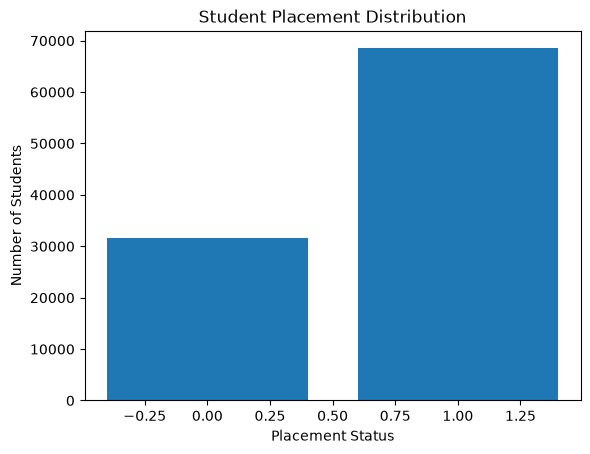

In [31]:
counts = df["placement_status"].value_counts()

plt.bar(counts.index, counts.values)
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.title("Student Placement Distribution")
plt.show()

## Analysis: Placement Status Distribution

### Observation:

- The dataset contains **68,475 placed students** and **31,525 unplaced students**.
- Approximately **68.48%** of students are placed, while **31.52%** are not placed.
- The target variable contains two classes, confirming that this is a **binary classification problem**.
- The two classes are not perfectly balanced, but both classes contain a substantial number of observations for model training.

In [37]:
branch_placement = df.groupby('branch')['placement_status'].mean()
branch_placement

branch
CE          0.646648
CSE         0.713487
Chemical    0.645532
ECE         0.695763
EE          0.663497
IT          0.708932
ME          0.664057
Name: placement_status, dtype: float64

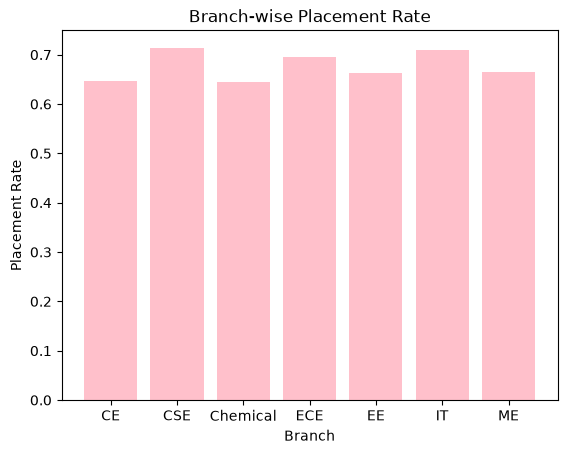

In [41]:
plt.bar(branch_placement.index, branch_placement.values, color='pink')
plt.xlabel("Branch")
plt.ylabel("Placement Rate")
plt.title("Branch-wise Placement Rate")
plt.show()

## Analysis: Branch-wise Placement Rate

### Observation:

- Placement rates vary across different academic branches.
- **CSE** has the highest placement rate at approximately **71.35%**.
- **IT** follows closely with a placement rate of approximately **70.89%**.
- **Chemical** has the lowest placement rate at approximately **64.55%**.
- The results suggest that academic branch may have some relationship with placement outcomes.
- However, branch alone does not determine placement, so other student-related factors should also be investigated.

In [46]:
college_tier_placement = df.groupby("college_tier")["placement_status"].mean()
college_tier_placement

college_tier
Tier-1    0.830576
Tier-2    0.725608
Tier-3    0.600747
Name: placement_status, dtype: float64

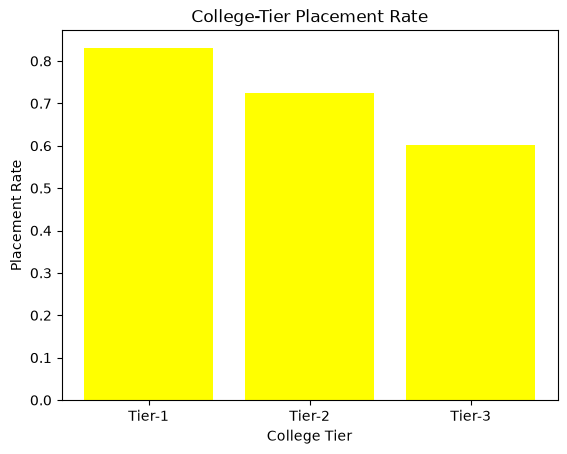

In [47]:
plt.bar(college_tier_placement.index, college_tier_placement.values, color='yellow')
plt.xlabel("College Tier")
plt.ylabel("Placement Rate")
plt.title("College-Tier Placement Rate")
plt.show()

## Analysis: College Tier-wise Placement Rate

### Observation:

- Placement rates show a clear difference across college tiers.
- **Tier-1 colleges** have the highest placement rate at approximately **83.06%**.
- **Tier-2 colleges** have a placement rate of approximately **72.56%**.
- **Tier-3 colleges** have the lowest placement rate at approximately **60.07%**.
- The results indicate that college tier may have a noticeable relationship with placement outcomes.
- However, this is an exploratory observation and does not establish that college tier alone causes higher placement rates.

In [51]:
cgpa_placement = df.groupby("placement_status")["cgpa"].mean()
cgpa_placement

placement_status
0    7.003297
1    7.299878
Name: cgpa, dtype: float64

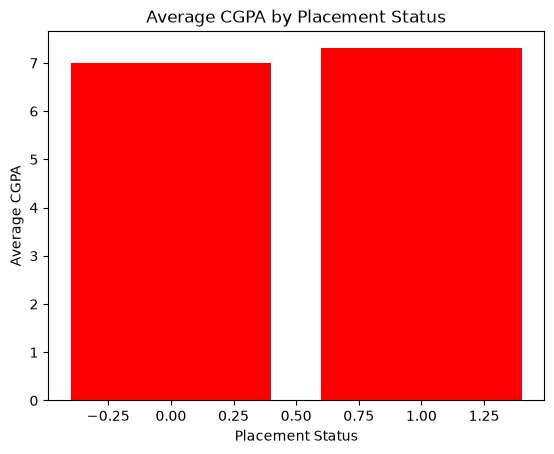

In [54]:
plt.bar(cgpa_placement.index, cgpa_placement.values, color='red')
plt.xlabel("Placement Status")
plt.ylabel("Average CGPA")
plt.title("Average CGPA by Placement Status")
plt.show()

## Analysis: Average CGPA by Placement Status

### Observation:

- Students who were placed have an average CGPA of approximately **7.30**.
- Students who were not placed have an average CGPA of approximately **7.00**.
- The placed group has an average CGPA about **0.30 points higher** than the unplaced group.
- This suggests that higher CGPA may be associated with better placement outcomes.
- However, CGPA alone does not determine placement, as other academic and skill-based factors may also contribute.

In [57]:
coding_placement = df.groupby("coding_skills")["placement_status"].mean()
coding_placement

coding_skills
1.0     0.660714
1.1     0.705882
1.2     0.411765
1.3     0.416667
1.4     0.619048
          ...   
9.6     0.807692
9.7     0.773585
9.8     0.778761
9.9     0.750000
10.0    0.795567
Name: placement_status, Length: 91, dtype: float64

In [58]:
df["coding_skill_range"] = pd.cut(
    df["coding_skills"],
    bins=[1, 2, 4, 6, 8, 10],
    labels=["Very Low", "Low", "Medium", "High", "Very High"],
    include_lowest=True
)

In [59]:
df["coding_skill_range"].value_counts().sort_index()

coding_skill_range
Very Low       474
Low           9141
Medium       41845
High         39885
Very High     8655
Name: count, dtype: int64

In [62]:
coding_range_placement = df.groupby("coding_skill_range")["placement_status"].mean()
coding_range_placement

coding_skill_range
Very Low     0.550633
Low          0.610436
Medium       0.663018
High         0.711245
Very High    0.753553
Name: placement_status, dtype: float64

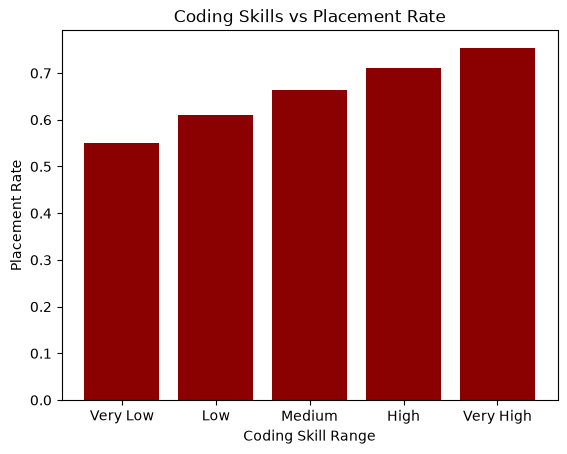

In [65]:
plt.bar(coding_range_placement.index, coding_range_placement.values, color='darkred')
plt.xlabel("Coding Skill Range")
plt.ylabel("Placement Rate")
plt.title("Coding Skills vs Placement Rate")
plt.show()

## Analysis: Coding Skills vs Placement Rate

### Observation:

- Placement rate generally increases as coding skill level increases.
- Students in the **Very Low** coding-skill group have a placement rate of approximately **55.06%**.
- The **Medium** group has a placement rate of approximately **66.30%**.
- The **High** group has a placement rate of approximately **71.12%**.
- The **Very High** group has the highest placement rate at approximately **75.36%**.
- This suggests a positive relationship between coding skills and placement outcomes.
- However, this relationship does not imply that coding skills alone determine placement.

In [66]:
internship_placement = df.groupby("internships")["placement_status"].mean()
internship_placement

internships
0    0.627645
1    0.682844
2    0.731837
3    0.771841
Name: placement_status, dtype: float64

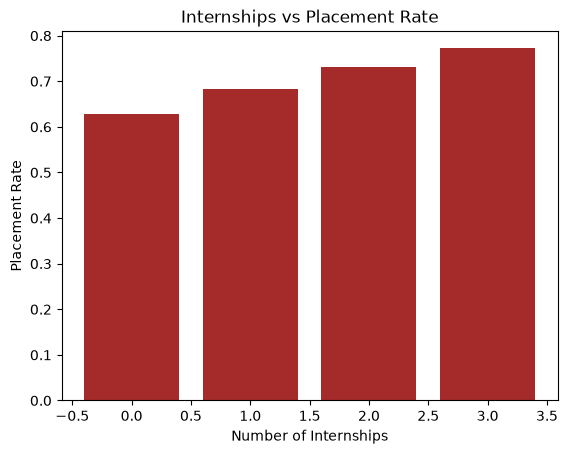

In [67]:
plt.bar(internship_placement.index, internship_placement.values, color='brown')
plt.xlabel("Number of Internships")
plt.ylabel("Placement Rate")
plt.title("Internships vs Placement Rate")
plt.show()